<a href="https://colab.research.google.com/github/Jasjotsingh136/UCS645-parllel-computing/blob/main/Parallel_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
from google.colab import files
uploaded = files.upload()

Saving for_parallel_project.jpeg to for_parallel_project (1).jpeg


In [12]:
%%writefile gaussian.cpp
#include <iostream>
#include <vector>
#include <cmath>
#include <fstream>
#include <omp.h>
#include <algorithm>

using namespace std;

#define KERNEL_SIZE 5
#define SIGMA 1.0

void createKernel(vector<vector<float>> &kernel) {
    int half = KERNEL_SIZE / 2;
    float sum = 0.0;

    for (int i = -half; i <= half; i++) {
        for (int j = -half; j <= half; j++) {
            float value = exp(-(i*i + j*j) / (2 * SIGMA * SIGMA));
            kernel[i + half][j + half] = value;
            sum += value;
        }
    }

    for (int i = 0; i < KERNEL_SIZE; i++)
        for (int j = 0; j < KERNEL_SIZE; j++)
            kernel[i][j] /= sum;
}

void loadImage(const char* filename,
               vector<vector<unsigned char>>& img,
               int &width, int &height) {

    ifstream file(filename, ios::binary);

    string format;
    file >> format >> width >> height;

    int maxval;
    file >> maxval;
    file.get();

    img.resize(height, vector<unsigned char>(width));

    for (int i = 0; i < height; i++) {
        file.read((char*)img[i].data(), width);
    }

    file.close();
}


void saveImage(const char* filename,
               vector<vector<unsigned char>>& img,
               int width, int height) {

    ofstream file(filename, ios::binary);

    file << "P5\n" << width << " " << height << "\n255\n";

    for (int i = 0; i < height; i++) {
        file.write((char*)img[i].data(), width);
    }

    file.close();
}


void gaussianBlur(vector<vector<unsigned char>> &input,
                  vector<vector<unsigned char>> &output,
                  vector<vector<float>> &kernel,
                  int width, int height) {

    int half = KERNEL_SIZE / 2;

    #pragma omp parallel for collapse(2)
    for (int i = 0; i < height; i++) {
        for (int j = 0; j < width; j++) {

            float sum = 0.0;

            for (int ki = -half; ki <= half; ki++) {
                for (int kj = -half; kj <= half; kj++) {

                    int ni = min(max(i + ki, 0), height - 1);
                    int nj = min(max(j + kj, 0), width - 1);

                    sum += input[ni][nj] * kernel[ki + half][kj + half];
                }
            }

            output[i][j] = (unsigned char)sum;
        }
    }
}


int main() {

    vector<vector<unsigned char>> input, output;
    vector<vector<float>> kernel(KERNEL_SIZE, vector<float>(KERNEL_SIZE));

    int width, height;


    loadImage("input.pgm", input, width, height);

    output.resize(height, vector<unsigned char>(width));

    createKernel(kernel);

    double start = omp_get_wtime();

    gaussianBlur(input, output, kernel, width, height);

    double end = omp_get_wtime();

    cout << "Processing done in " << (end - start) << " seconds\n";


    saveImage("output.pgm", output, width, height);

    return 0;
}

Overwriting gaussian.cpp


In [18]:
!convert "for_parallel_project.jpeg" -colorspace Gray input.pgm

In [19]:
!g++ -O2 -fopenmp gaussian.cpp -o blur

In [20]:
!./blur

Processing done in 0.155219 seconds


In [21]:
!convert output.pgm output.png

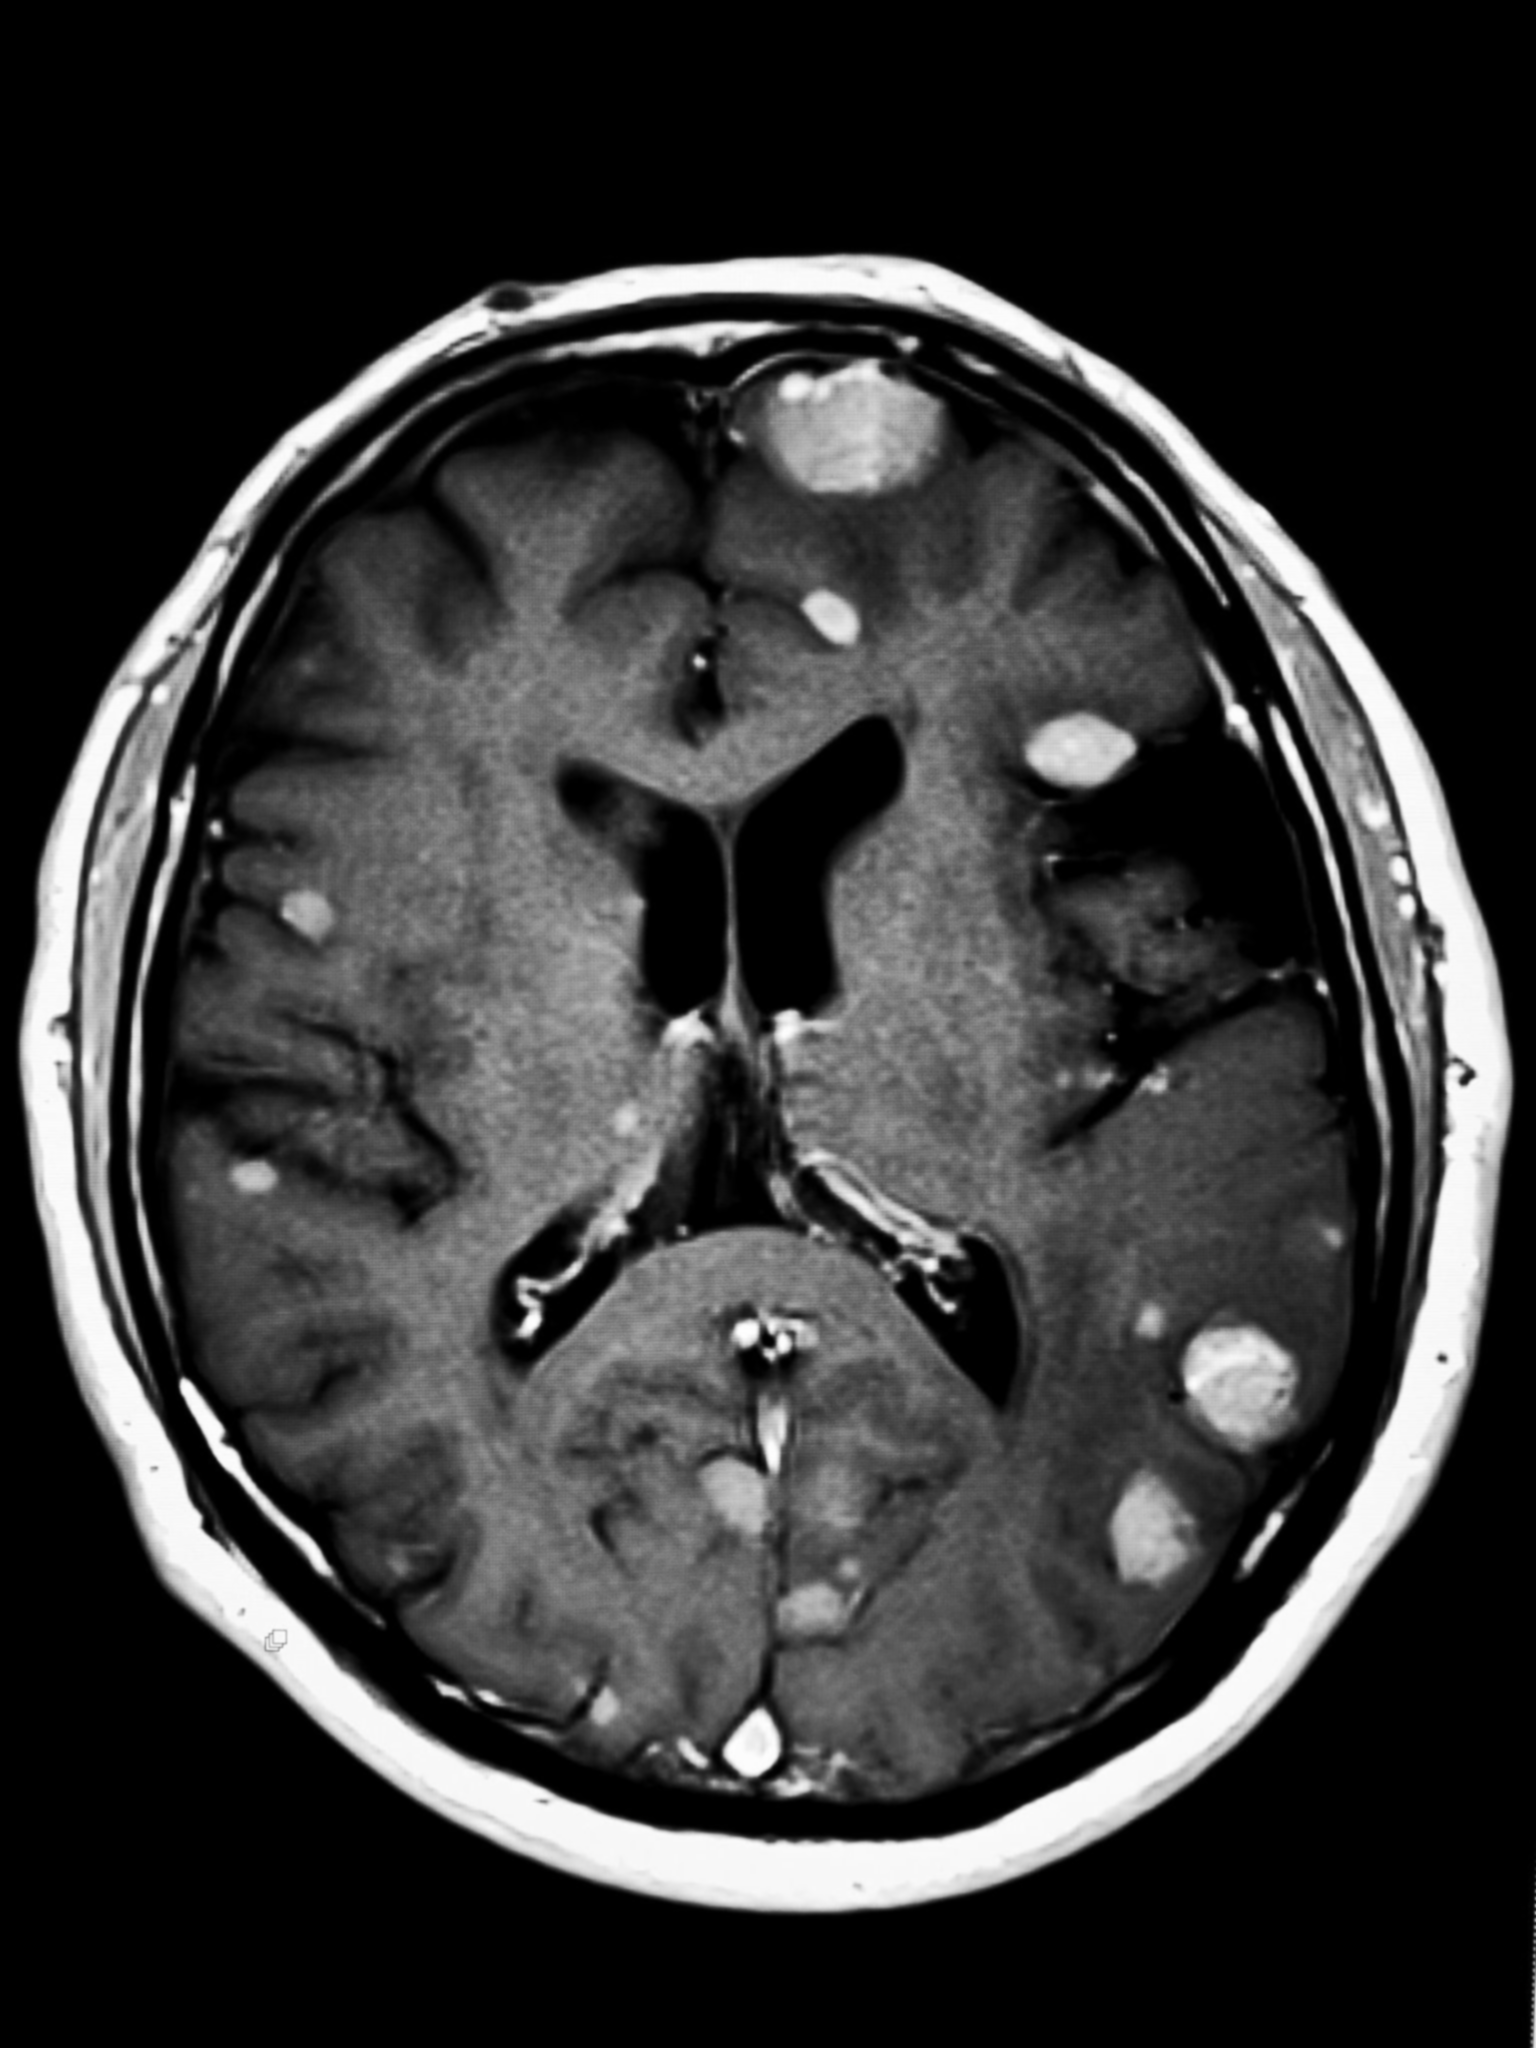

In [22]:
from IPython.display import Image, display
display(Image("output.png"))